In [14]:
import os
import pandas as pd

print("Dossier actuel :", os.getcwd())

df = pd.read_csv(r"C:\Users\souai\OneDrive\Bureau\projet machine learning\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

Dossier actuel : c:\Users\souai\OneDrive\Bureau\projet machine learning
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [22]:
import numpy as np

# copie du dataset original
df_clean = df.copy()

# 1) supprimer customerID
df_clean.drop("customerID", axis=1, inplace=True)

# 2) remplacer les chaînes vides dans TotalCharges par NaN
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(" ", np.nan)

# 3) convertir TotalCharges en numérique
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"])

# 4) vérifier les valeurs manquantes après conversion
print(df_clean.isnull().sum())

# 5) supprimer les lignes avec valeurs manquantes
df_clean.dropna(inplace=True)

# 6) vérifier la nouvelle taille du dataset
print(df_clean.shape)

# 7) vérifier les types finaux
df_clean.info()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


(7032, 20)
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  

In [23]:
# transformer la variable cible
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# vérifier
df_clean["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [24]:
# séparer les variables explicatives et la cible
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5625, 19) (1407, 19) (5625,) (1407,)


In [26]:
# transformer la cible
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# séparer variables explicatives et cible
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

# encoder les variables catégorielles
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [27]:
df_clean["Churn"].unique()

array([nan])

In [28]:
import numpy as np
import pandas as pd

# repartir du dataset original
df_clean = df.copy()

# supprimer la colonne identifiant
df_clean.drop("customerID", axis=1, inplace=True)

# nettoyer TotalCharges
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(" ", np.nan)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"])

# supprimer les lignes avec valeurs manquantes
df_clean.dropna(inplace=True)

# transformer Churn UNE SEULE FOIS
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# vérification
print(df_clean.shape)
print(df_clean["Churn"].unique())
print(df_clean["Churn"].isnull().sum())
print(df_clean["Churn"].value_counts())

(7032, 20)
[0 1]
0
Churn
0    5163
1    1869
Name: count, dtype: int64


In [29]:
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(y.shape)
print(y.isnull().sum())

(7032, 30)
(7032,)
0


In [30]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(5625, 30) (1407, 30) (5625,) (1407,)


In [31]:
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

x_train_sc = x_train.copy()
x_test_sc = x_test.copy()

scaler = StandardScaler()
x_train_sc[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_sc[num_cols] = scaler.transform(x_test[num_cols])

x_train_sc.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,-0.439319,1.321816,0.981556,1.659900,True,True,True,True,False,True,...,False,False,False,False,False,True,False,True,False,False
7003,-0.439319,-0.267410,-0.971546,-0.562252,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3355,-0.439319,1.444064,0.837066,1.756104,False,True,False,True,False,True,...,False,False,False,False,False,True,False,True,False,False
4494,-0.439319,-1.204646,0.641092,-0.908326,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3541,-0.439319,0.669826,-0.808787,-0.101561,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


In [32]:
X = df_clean.drop("Churn", axis=1)  # Variables explicatives
y = df_clean["Churn"]  # Cible (la colonne Churn)

In [33]:
from sklearn.model_selection import train_test_split

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5625, 19) (1407, 19) (5625,) (1407,)


In [34]:
from sklearn.preprocessing import StandardScaler

# Liste des colonnes à mettre à l'échelle
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

# Copier les données pour ne pas les modifier directement
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

# Appliquer le scaling sur les colonnes sélectionnées
scaler = StandardScaler()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test[num_cols])

# Vérification
print(X_train_sc.head())  # Affiche les premières lignes pour vérifier

      gender  SeniorCitizen Partner Dependents    tenure PhoneService  \
1413    Male      -0.439319     Yes        Yes  1.321816          Yes   
7003    Male      -0.439319      No         No -0.267410           No   
3355  Female      -0.439319     Yes         No  1.444064          Yes   
4494    Male      -0.439319      No         No -1.204646          Yes   
3541  Female      -0.439319     Yes         No  0.669826           No   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
1413               Yes     Fiber optic            Yes          Yes   
7003  No phone service             DSL             No           No   
3355               Yes     Fiber optic             No          Yes   
4494                No     Fiber optic             No          Yes   
3541  No phone service             DSL            Yes           No   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
1413              Yes         Yes          No              

In [35]:
# Encoder les variables catégorielles en variables numériques (One-Hot Encoding)
df_clean_encoded = pd.get_dummies(df_clean, drop_first=True)

# Séparer les variables explicatives et la cible
X = df_clean_encoded.drop("Churn", axis=1)  # Variables explicatives
y = df_clean_encoded["Churn"]  # Cible

In [36]:
print(df_clean.isnull().sum())  # Affiche le nombre de valeurs manquantes par colonne

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [37]:
from sklearn.model_selection import train_test_split

# Diviser les données en jeu d'entraînement et de test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
from sklearn.preprocessing import StandardScaler

# Liste des colonnes numériques à standardiser
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Copie des données pour éviter de les modifier directement
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

# Appliquer le scaling sur les colonnes sélectionnées
scaler = StandardScaler()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test[num_cols])

# Vérification
print(X_train_sc.head())  # Afficher les premières lignes pour vérifier

      SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
1413              0  1.321816        0.981556      1.659900         True   
7003              0 -0.267410       -0.971546     -0.562252         True   
3355              0  1.444064        0.837066      1.756104        False   
4494              0 -1.204646        0.641092     -0.908326         True   
3541              0  0.669826       -0.808787     -0.101561        False   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
1413         True            True              True   
7003        False           False             False   
3355         True           False              True   
4494        False           False              True   
3541         True           False             False   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
1413                           False               True  ...   
7003                            True              False  ...   
3355                

In [39]:
from sklearn.linear_model import LogisticRegression

# Créer l'instance du modèle
LR = LogisticRegression(max_iter=1000)

# Entraîner le modèle sur les données d'entraînement
LR.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

1.Matrice de confusion


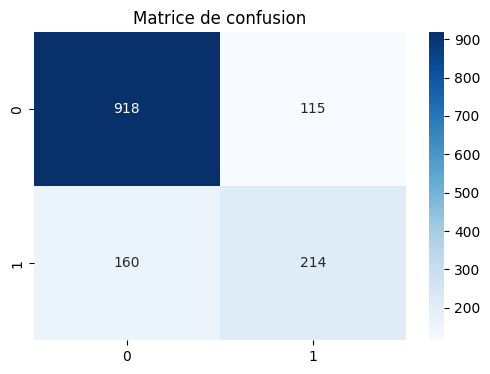

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Faire des prédictions sur le jeu de test
y_predictLR = LR.predict(X_test_sc)

# Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_predictLR)

# Afficher la matrice de confusion avec seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.show()

# Afficher le rapport de classification
print(classification_report(y_test, y_predictLR))

2.Création du modèle KNN

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5) # n_neighbors (K) est un hyper paramètre choisissez la valeur que vous voulez

In [42]:
from sklearn.neighbors import KNeighborsClassifier

# Créer l'instance du modèle KNN avec 5 voisins (tu peux ajuster ce paramètre)
knn = KNeighborsClassifier(n_neighbors=5)

# Entraîner le modèle sur les données d'entraînement
knn.fit(X_train_sc, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Définir le modèle (KNN ici)
model = KNeighborsClassifier()

# Définir la grille de paramètres (exemple)
parameters = {
    'n_neighbors': [3, 5, 7, 10],  # Teste différentes valeurs pour K
    'metric': ['euclidean', 'manhattan']  # Exemple de métriques à tester
}

# GridSearchCV pour rechercher les meilleurs paramètres
clf = GridSearchCV(
    estimator=model,
    param_grid=parameters,
    scoring='recall',  # Choisir 'recall' comme métrique d'évaluation
    cv=5  # Validation croisée avec 5 plis
)

# Appliquer GridSearchCV
clf.fit(X_train_sc, y_train)

# Afficher les meilleurs paramètres et le score
print(f"Meilleurs paramètres: {clf.best_params_}")
print(f"Meilleur score (recall): {clf.best_score_}")

Meilleurs paramètres: {'metric': 'manhattan', 'n_neighbors': 7}
Meilleur score (recall): 0.5531772575250835


In [44]:
grille = clf.fit(X_train_sc, y_train)

Courbe d'apprentissage 


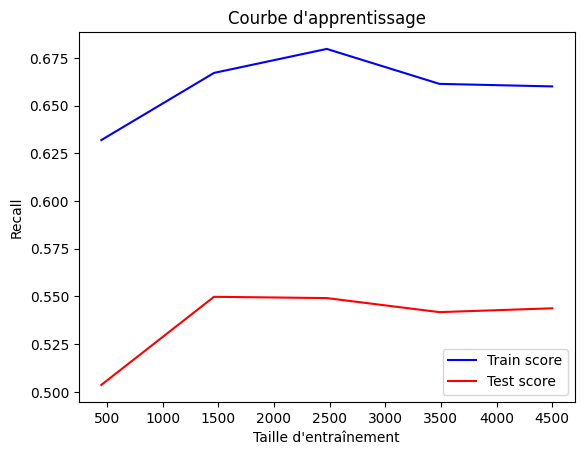

In [45]:
from sklearn.model_selection import learning_curve

# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model, X=X_train_sc, y=y_train, cv=5, scoring='recall', n_jobs=-1
)

# Moyenne et écart type des scores d'entraînement et de test
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Tracé des courbes d'apprentissage
plt.plot(train_sizes, train_mean, label='Train score', color='blue')
plt.plot(train_sizes, test_mean, label='Test score', color='red')
plt.title("Courbe d'apprentissage")
plt.xlabel("Taille d'entraînement")
plt.ylabel("Recall")
plt.legend()
plt.show()

3.Visualisation des performances de GridSearchCV

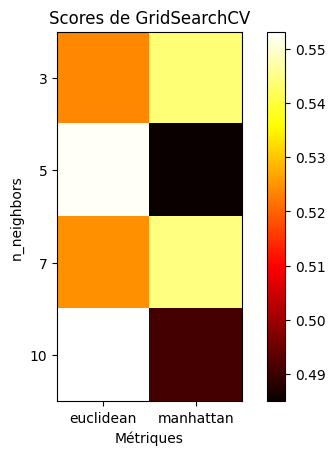

In [46]:
import matplotlib.pyplot as plt

# Visualisation de la performance du GridSearchCV
scores_matrix = clf.cv_results_['mean_test_score'].reshape(len(parameters['n_neighbors']), len(parameters['metric']))

plt.imshow(scores_matrix, interpolation='nearest', cmap=plt.cm.hot)
plt.xlabel('Métriques')
plt.ylabel('n_neighbors')
plt.title("Scores de GridSearchCV")
plt.xticks(np.arange(len(parameters['metric'])), parameters['metric'])
plt.yticks(np.arange(len(parameters['n_neighbors'])), parameters['n_neighbors'])
plt.colorbar()
plt.show()

4.Courbe ROC (Receiver Operating Characteristic)

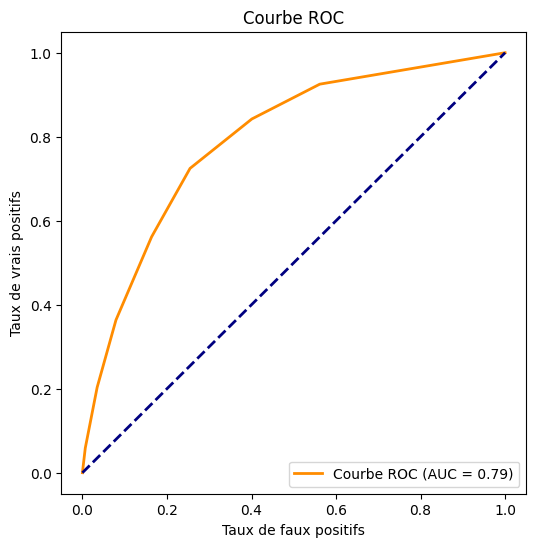

In [47]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test_sc)[:, 1])
roc_auc = auc(fpr, tpr)

# Tracé de la courbe ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Courbe ROC")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend(loc="lower right")
plt.show()

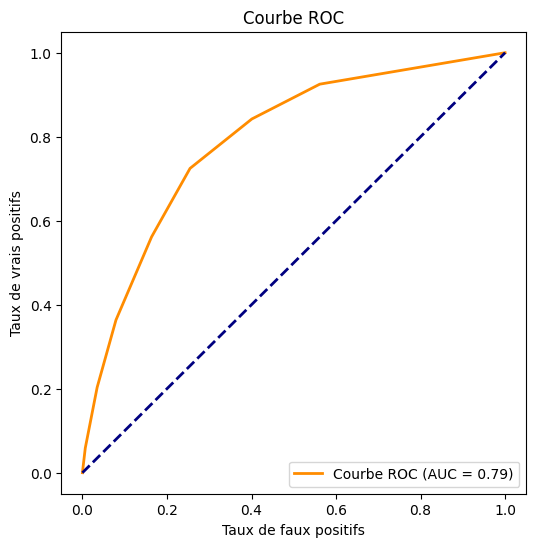

In [48]:
from sklearn.metrics import auc

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test_sc)[:, 1])
roc_auc = auc(fpr, tpr)

# Tracé de la courbe ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Courbe ROC")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend(loc="lower right")
plt.show()

Modèle SVM avec kernel RBF


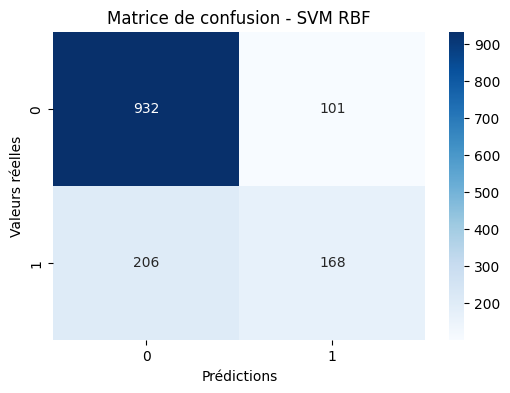

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.45      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [49]:


from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Créer le modèle SVM avec kernel RBF
SVC_RBF = SVC(kernel="rbf", C=1, gamma=1)

# Entraîner le modèle
SVC_RBF.fit(X_train_sc, y_train)

# Prédiction sur les données de test
SVC_predict_RBF = SVC_RBF.predict(X_test_sc)

# Matrice de confusion
cm = confusion_matrix(y_test, SVC_predict_RBF)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - SVM RBF")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

# Rapport de classification
print(classification_report(y_test, SVC_predict_RBF))

Grid Search SVM - Kernel RBF

In [50]:


from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Définir le modèle
model = SVC(kernel="rbf")

# Paramètres à tester
parameters = {
    "C": [0.1, 1, 10],
    "gamma": [0.01, 0.1, 1]
}

# Grid Search avec recall
grid_rbf = GridSearchCV(
    estimator=model,
    param_grid=parameters,
    scoring="recall",
    cv=5
)

# Entraînement du Grid Search
grid_rbf.fit(X_train_sc, y_train)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres :", grid_rbf.best_params_)
print("Meilleur score recall :", grid_rbf.best_score_)

KeyboardInterrupt: 

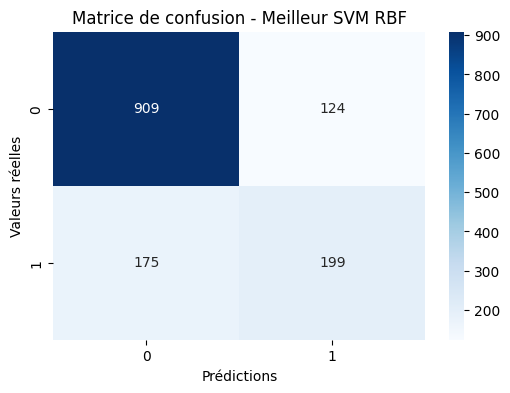

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
# =========================
# Évaluation du meilleur modèle SVM
# =========================

best_SVC_RBF = grid_rbf.best_estimator_

SVC_predict_best = best_SVC_RBF.predict(X_test_sc)

cm = confusion_matrix(y_test, SVC_predict_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - Meilleur SVM RBF")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

print(classification_report(y_test, SVC_predict_best))

decision tree classifier


Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 2, 'max_features': 5}
Meilleur score recall : 0.4499284116331096


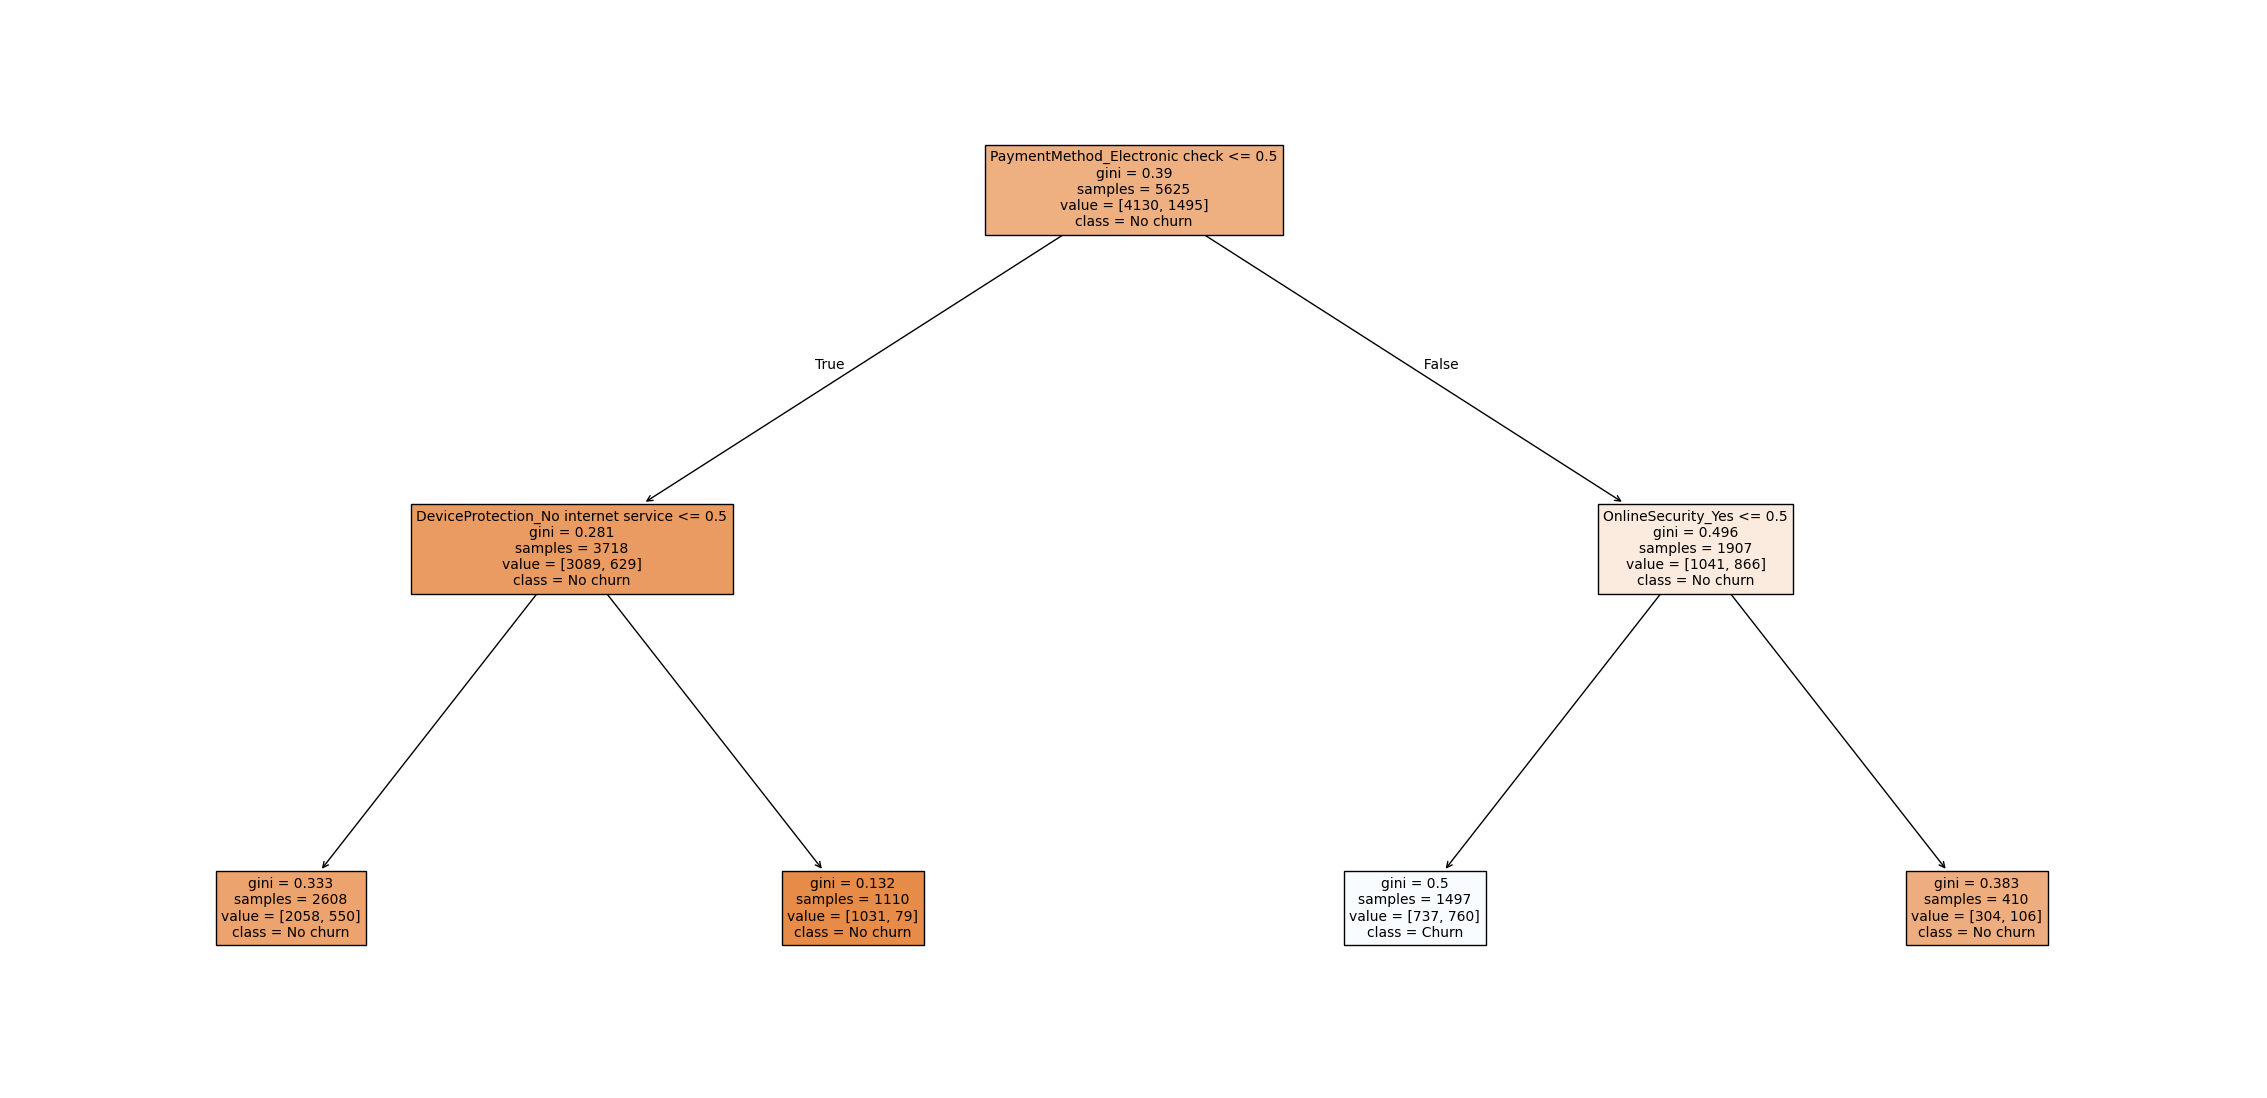

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# modèle de base
tree_model = DecisionTreeClassifier(random_state=42)

# grille des paramètres
tree_params = {
    'max_depth': range(1, 4),
    'max_features': range(3, 6),
    'criterion': ['gini', 'entropy']
}

# Grid Search avec recall
tree_classifier = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_params,
    cv=10,
    scoring='recall'
)

# entraînement
tree_classifier.fit(X_train, y_train)

# meilleurs paramètres et meilleur score
print("Meilleurs paramètres :", tree_classifier.best_params_)
print("Meilleur score recall :", tree_classifier.best_score_)

# affichage de l'arbre optimal
plt.figure(figsize=(29, 14))
plot_tree(
    tree_classifier.best_estimator_,
    class_names=['No churn', 'Churn'],
    feature_names=X_train.columns,
    filled=True,
    fontsize=10
)
plt.show()

In [ ]:
tree_classifier.best_params_, tree_classifier.best_score_

({'criterion': 'gini', 'max_depth': 2, 'max_features': 5},
 np.float64(0.4499284116331096))

 Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from pprint import pprint

rf = RandomForestClassifier(random_state=42)

print("Parameters currently in use:\n")
pprint(rf.get_params())

Parameters currently in use:

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


In [ ]:
n_estimators = [200, 300, 400, 500]
max_features = [3, 4, 5, 6]
max_depth = [2, 3, 4, 5]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

param_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}

print(param_grid)

{'n_estimators': [200, 300, 400, 500], 'max_features': [3, 4, 5, 6], 'max_depth': [2, 3, 4, 5], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


GridSearchCV pour trouver le meilleur Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_features': [3, 5],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Meilleurs paramètres :", rf_grid.best_params_)
print("Meilleur score recall :", rf_grid.best_score_)



Meilleurs paramètres : {'bootstrap': True, 'max_depth': 5, 'max_features': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score recall : 0.44348670567373033


Tester le meilleur modèle

In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

Matrice de confusion

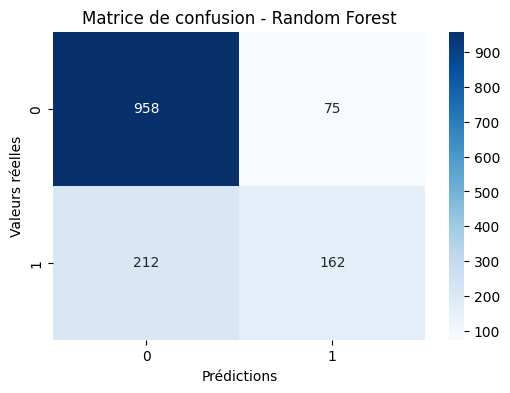

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1033
           1       0.68      0.43      0.53       374

    accuracy                           0.80      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.80      0.78      1407



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

print(classification_report(y_test, y_pred_rf))

Courbe ROC du modèle Random Forest

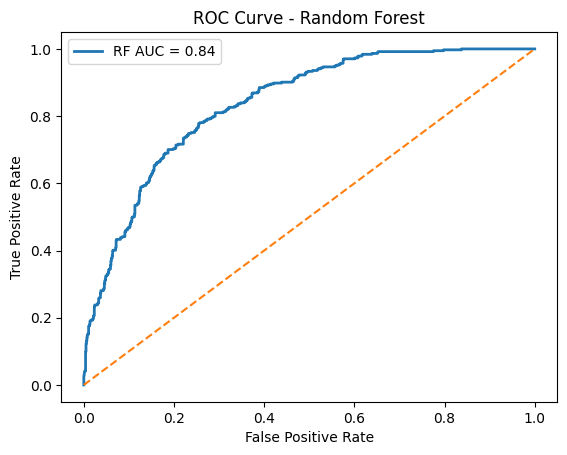

In [ ]:
from sklearn import metrics

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thr_rf = metrics.roc_curve(y_test, y_prob_rf)
auc_rf = metrics.auc(fpr_rf, tpr_rf)

plt.plot(fpr_rf, tpr_rf, lw=2, label='RF AUC = %0.2f' % auc_rf)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

 Sauvegarde du meilleur modèle avec Pickle

In [ ]:
import pickle

# sauvegarder le modèle
pickle.dump(best_rf, open('churn_random_forest.pkl', 'wb'))

In [ ]:
loaded_model = pickle.load(open('churn_random_forest.pkl', 'rb'))

### Sauvegarde du meilleur modèle avec Pickle

In [ ]:
y_pred_loaded = loaded_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_loaded))

[[958  75]
 [212 162]]


XGBoost

In [ ]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\souai\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from xgboost import XGBClassifier

# créer le modèle
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# entraînement
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

Matrice de confusion

In [51]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - XGBoost")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

print(classification_report(y_test, y_pred_xgb))

NameError: name 'y_pred_xgb' is not defined

XGBoost avec GridSearchCV

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Meilleurs paramètres :", xgb_grid.best_params_)
print("Meilleur score recall :", xgb_grid.best_score_)

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

NameError: name 'xgb_grid' is not defined

Sauvegarder le meilleur modèle

In [ ]:
best_model = LR

NameError: name 'LR' is not defined

In [ ]:
import pickle
pickle.dump(best_model, open("best_churn_model.pkl", "wb"))

NameError: name 'best_model' is not defined

In [ ]:
best_model = LR

NameError: name 'LR' is not defined

# 7. Suppléments finaux du projet

Cette partie complète le notebook sans supprimer ni modifier les cellules précédentes. Elle ajoute les éléments attendus pour la version finale : synthèse CRISP-DM, comparaison des modèles, choix du meilleur modèle, sauvegarde du modèle et préparation de l'application Streamlit.

## 7.1 Synthèse CRISP-DM finale

### Business Understanding
L'objectif du projet est de prédire le **churn client** dans une entreprise de télécommunication. Le churn signifie qu'un client quitte l'entreprise ou résilie son abonnement. L'enjeu métier est important, car conserver un client coûte généralement moins cher que d'en acquérir un nouveau.

**Problématique métier :** comment identifier les clients ayant un risque élevé de quitter l'entreprise ?

**Objectif ML :** construire un modèle de classification binaire capable de prédire si un client appartient à la classe :
- `0` : No churn, le client reste ;
- `1` : Churn, le client quitte l'entreprise.

**Indicateurs de performance utilisés :** accuracy, precision, recall, f1-score et ROC-AUC. Dans ce projet, le **recall de la classe 1** est particulièrement important, car il mesure la capacité du modèle à détecter les clients qui risquent réellement de partir.

### Data Understanding
Le dataset utilisé est le dataset **Telco Customer Churn**. Il contient des informations sur les clients : ancienneté, type de contrat, services internet, mode de paiement, frais mensuels, frais totaux et variable cible `Churn`.

### Data Preparation
Les principales étapes de préparation réalisées sont : suppression de `customerID`, conversion de `TotalCharges` en numérique, traitement des valeurs manquantes, transformation de `Churn` en 0/1, encodage des variables catégorielles avec `pd.get_dummies`, séparation train/test et standardisation des variables numériques pour les modèles sensibles à l'échelle.

### Modeling
Plusieurs modèles de classification ont été testés : Logistic Regression, KNN, SVM, Decision Tree, Random Forest et XGBoost.

### Evaluation
Les modèles sont comparés à l'aide des métriques de classification, en donnant une attention particulière au recall et au f1-score de la classe `1`.

## 7.2 Tableau comparatif final des modèles

Cette cellule compare automatiquement les modèles déjà entraînés dans le notebook. Elle utilise `X_test_sc` pour les modèles qui nécessitent la standardisation et `X_test` pour les modèles basés sur des arbres.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

results = []
model_objects = {}
model_uses_scaled_data = {}

def evaluate_model(name, model, X_eval, uses_scaled):
    """Évalue un modèle et ajoute ses résultats dans le tableau comparatif."""
    y_pred = model.predict(X_eval)

    # ROC-AUC si possible
    auc_value = np.nan
    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_eval)[:, 1]
            auc_value = roc_auc_score(y_test, y_score)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_eval)
            auc_value = roc_auc_score(y_test, y_score)
    except Exception:
        auc_value = np.nan

    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Classe_1": precision_score(y_test, y_pred, zero_division=0),
        "Recall_Classe_1": recall_score(y_test, y_pred, zero_division=0),
        "F1_Classe_1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc_value
    })
    model_objects[name] = model
    model_uses_scaled_data[name] = uses_scaled

# Modèles entraînés avec les données standardisées
if "LR" in globals():
    evaluate_model("Logistic Regression", LR, X_test_sc, True)

if "knn" in globals():
    evaluate_model("KNN", knn, X_test_sc, True)

if "clf" in globals() and hasattr(clf, "best_estimator_"):
    evaluate_model("KNN GridSearch", clf.best_estimator_, X_test_sc, True)

if "SVC_RBF" in globals():
    evaluate_model("SVM RBF", SVC_RBF, X_test_sc, True)

if "grid_rbf" in globals() and hasattr(grid_rbf, "best_estimator_"):
    evaluate_model("SVM RBF GridSearch", grid_rbf.best_estimator_, X_test_sc, True)

# Modèles entraînés avec les données non standardisées
if "tree_classifier" in globals() and hasattr(tree_classifier, "best_estimator_"):
    evaluate_model("Decision Tree GridSearch", tree_classifier.best_estimator_, X_test, False)

if "best_rf" in globals():
    evaluate_model("Random Forest", best_rf, X_test, False)
elif "rf_grid" in globals() and hasattr(rf_grid, "best_estimator_"):
    evaluate_model("Random Forest", rf_grid.best_estimator_, X_test, False)

if "xgb_model" in globals():
    evaluate_model("XGBoost", xgb_model, X_test, False)

if "best_xgb" in globals():
    evaluate_model("XGBoost GridSearch", best_xgb, X_test, False)
elif "xgb_grid" in globals() and hasattr(xgb_grid, "best_estimator_"):
    evaluate_model("XGBoost GridSearch", xgb_grid.best_estimator_, X_test, False)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(
    by=["Recall_Classe_1", "F1_Classe_1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

comparison_df

KeyError: 'Recall_Classe_1'

## 7.3 Choix automatique du meilleur modèle

Pour un problème de churn, le modèle final est choisi en priorité selon le **recall de la classe 1**, car l'objectif est de détecter un maximum de clients qui risquent de partir. En cas d'égalité, on regarde le f1-score puis l'accuracy.

In [ ]:
# Choix du meilleur modèle selon recall classe 1, puis f1-score, puis accuracy
best_model_name = comparison_df.iloc[0]["Modèle"]
best_model = model_objects[best_model_name]
best_model_uses_scaled = model_uses_scaled_data[best_model_name]

print("Meilleur modèle retenu :", best_model_name)
print("Utilise les données standardisées :", best_model_uses_scaled)
print("Résultats du meilleur modèle :")
display(comparison_df.iloc[[0]])

NameError: name 'comparison_df' is not defined

## 7.4 Évaluation finale du meilleur modèle

Cette partie affiche la matrice de confusion et le rapport de classification du modèle retenu.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

X_final_test = X_test_sc if best_model_uses_scaled else X_test

y_pred_best = best_model.predict(X_final_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"])
plt.title("Matrice de confusion - Meilleur modèle")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

print(classification_report(y_test, y_pred_best))

NameError: name 'best_model_uses_scaled' is not defined

## 7.5 Courbe ROC du meilleur modèle

La courbe ROC permet de visualiser la capacité du modèle à séparer les clients `Churn` et `No churn`. Plus l'AUC est proche de 1, meilleur est le modèle.

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

X_final_test = X_test_sc if best_model_uses_scaled else X_test

y_score = None

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_final_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_score = best_model.decision_function(X_final_test)

if y_score is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{best_model_name} - AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Courbe ROC - Meilleur modèle")
    plt.legend()
    plt.show()
else:
    print("Ce modèle ne fournit pas de probabilité ou de score pour tracer la courbe ROC.")

NameError: name 'best_model_uses_scaled' is not defined

## 7.6 Importance des variables

Cette partie aide à interpréter le modèle final. Elle affiche les variables les plus importantes si le modèle le permet.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train.columns

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 5))
    importances.sort_values().plot(kind="barh")
    plt.title("Top 15 des variables les plus importantes")
    plt.xlabel("Importance")
    plt.show()
    display(importances.to_frame("Importance"))

elif hasattr(best_model, "coef_"):
    coefs = pd.Series(best_model.coef_[0], index=feature_names).sort_values(key=abs, ascending=False).head(15)
    plt.figure(figsize=(8, 5))
    coefs.sort_values().plot(kind="barh")
    plt.title("Top 15 des coefficients les plus influents")
    plt.xlabel("Coefficient")
    plt.show()
    display(coefs.to_frame("Coefficient"))

else:
    print("Ce modèle ne permet pas d'afficher directement l'importance des variables.")

NameError: name 'X_train' is not defined

## 7.7 Sauvegarde finale du modèle

Cette cellule sauvegarde le meilleur modèle, les colonnes d'entraînement, les variables numériques et le scaler. Ces éléments seront utilisés par l'application Streamlit.

In [ ]:
import pickle

model_package = {
    "model": best_model,
    "model_name": best_model_name,
    "columns": X_train.columns.tolist(),
    "num_cols": num_cols,
    "scaler": scaler,
    "uses_scaled": best_model_uses_scaled
}

with open("best_churn_package.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("Modèle sauvegardé dans : best_churn_package.pkl")
print("Modèle final :", best_model_name)

NameError: name 'best_model' is not defined

## 7.8 Création de l'application Streamlit

Cette cellule génère un fichier `app.py`. Après exécution du notebook, lance l'application avec la commande suivante dans le terminal :

```bash
streamlit run app.py
```

In [ ]:
streamlit_code = r"""
import streamlit as st
import pandas as pd
import pickle

st.set_page_config(page_title="Churn Prediction", page_icon="📊", layout="centered")

st.title("📊 Prédiction du churn client")
st.write("Cette application prédit si un client risque de quitter l'entreprise télécom.")

# Charger le modèle et les informations de préparation
with open("best_churn_package.pkl", "rb") as file:
    package = pickle.load(file)

model = package["model"]
columns = package["columns"]
num_cols = package["num_cols"]
scaler = package["scaler"]
uses_scaled = package["uses_scaled"]
model_name = package["model_name"]

st.sidebar.header("Informations client")
st.sidebar.write(f"Modèle utilisé : **{model_name}**")

# Variables numériques
tenure = st.number_input("Ancienneté du client (tenure)", min_value=0, max_value=100, value=12)
monthly_charges = st.number_input("MonthlyCharges", min_value=0.0, max_value=200.0, value=70.0)
total_charges = st.number_input("TotalCharges", min_value=0.0, max_value=10000.0, value=900.0)
senior = st.selectbox("SeniorCitizen", [0, 1])

# Variables catégorielles principales
gender = st.selectbox("Gender", ["Female", "Male"])
partner = st.selectbox("Partner", ["No", "Yes"])
dependents = st.selectbox("Dependents", ["No", "Yes"])
phone_service = st.selectbox("PhoneService", ["No", "Yes"])
multiple_lines = st.selectbox("MultipleLines", ["No", "Yes", "No phone service"])
internet_service = st.selectbox("InternetService", ["DSL", "Fiber optic", "No"])
online_security = st.selectbox("OnlineSecurity", ["No", "Yes", "No internet service"])
online_backup = st.selectbox("OnlineBackup", ["No", "Yes", "No internet service"])
device_protection = st.selectbox("DeviceProtection", ["No", "Yes", "No internet service"])
tech_support = st.selectbox("TechSupport", ["No", "Yes", "No internet service"])
streaming_tv = st.selectbox("StreamingTV", ["No", "Yes", "No internet service"])
streaming_movies = st.selectbox("StreamingMovies", ["No", "Yes", "No internet service"])
contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
paperless_billing = st.selectbox("PaperlessBilling", ["No", "Yes"])
payment_method = st.selectbox("PaymentMethod", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])

# Construire une ligne avec toutes les colonnes attendues
input_data = pd.DataFrame([[0] * len(columns)], columns=columns)

# Remplir les variables numériques si elles existent
for col, val in {
    "SeniorCitizen": senior,
    "tenure": tenure,
    "MonthlyCharges": monthly_charges,
    "TotalCharges": total_charges
}.items():
    if col in input_data.columns:
        input_data.loc[0, col] = val

# Fonction pratique pour activer une colonne encodée si elle existe
def set_dummy(column_name, condition=True):
    if condition and column_name in input_data.columns:
        input_data.loc[0, column_name] = 1

set_dummy("gender_Male", gender == "Male")
set_dummy("Partner_Yes", partner == "Yes")
set_dummy("Dependents_Yes", dependents == "Yes")
set_dummy("PhoneService_Yes", phone_service == "Yes")
set_dummy("MultipleLines_Yes", multiple_lines == "Yes")
set_dummy("MultipleLines_No phone service", multiple_lines == "No phone service")
set_dummy("InternetService_Fiber optic", internet_service == "Fiber optic")
set_dummy("InternetService_No", internet_service == "No")
set_dummy("OnlineSecurity_Yes", online_security == "Yes")
set_dummy("OnlineSecurity_No internet service", online_security == "No internet service")
set_dummy("OnlineBackup_Yes", online_backup == "Yes")
set_dummy("OnlineBackup_No internet service", online_backup == "No internet service")
set_dummy("DeviceProtection_Yes", device_protection == "Yes")
set_dummy("DeviceProtection_No internet service", device_protection == "No internet service")
set_dummy("TechSupport_Yes", tech_support == "Yes")
set_dummy("TechSupport_No internet service", tech_support == "No internet service")
set_dummy("StreamingTV_Yes", streaming_tv == "Yes")
set_dummy("StreamingTV_No internet service", streaming_tv == "No internet service")
set_dummy("StreamingMovies_Yes", streaming_movies == "Yes")
set_dummy("StreamingMovies_No internet service", streaming_movies == "No internet service")
set_dummy("Contract_One year", contract == "One year")
set_dummy("Contract_Two year", contract == "Two year")
set_dummy("PaperlessBilling_Yes", paperless_billing == "Yes")
set_dummy("PaymentMethod_Credit card (automatic)", payment_method == "Credit card (automatic)")
set_dummy("PaymentMethod_Electronic check", payment_method == "Electronic check")
set_dummy("PaymentMethod_Mailed check", payment_method == "Mailed check")

# Standardisation si le modèle final l'exige
input_for_prediction = input_data.copy()
if uses_scaled and scaler is not None:
    existing_num_cols = [col for col in num_cols if col in input_for_prediction.columns]
    input_for_prediction[existing_num_cols] = scaler.transform(input_for_prediction[existing_num_cols])

if st.button("Prédire"):
    prediction = model.predict(input_for_prediction)[0]

    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(input_for_prediction)[0][1]

    if prediction == 1:
        st.error("Résultat : le client risque de quitter l'entreprise (Churn).")
    else:
        st.success("Résultat : le client ne semble pas risquer de quitter l'entreprise (No churn).")

    if proba is not None:
        st.write(f"Probabilité estimée de churn : **{proba:.2%}**")

st.caption("Projet Machine Learning - Telco Customer Churn")
"""

with open("app.py", "w", encoding="utf-8") as file:
    file.write(streamlit_code)

print("Fichier Streamlit créé : app.py")
print("Pour lancer l'application : streamlit run app.py")

Fichier Streamlit créé : app.py
Pour lancer l'application : streamlit run app.py


## 7.9 Conclusion finale prête pour le rapport

Le projet a permis de construire un système de prédiction du churn client à partir du dataset Telco Customer Churn. Après nettoyage, encodage et préparation des données, plusieurs modèles de classification ont été entraînés et comparés : Logistic Regression, KNN, SVM, Decision Tree, Random Forest et XGBoost.

Le choix du meilleur modèle est basé principalement sur le **recall de la classe 1**, car l'objectif métier est de détecter les clients qui risquent réellement de quitter l'entreprise. Le modèle final peut être utilisé pour identifier les clients à risque et mettre en place des actions de fidélisation ciblées.

D'un point de vue business, les variables liées au contrat, au mode de paiement, à l'ancienneté du client et aux services internet peuvent influencer fortement le churn. L'entreprise peut donc utiliser ces informations pour réduire le taux de départ, améliorer la satisfaction client et proposer des offres adaptées aux profils les plus risqués.